# Fase 3 — Capítulo 10: A Primeira Técnica de Aprendizado de Máquina

## ATIVIDADE — Modelagem de IA da FarmTech Solutions

### Integrantes do grupo

| Aluno | RM |
|---|---|
| Lucas Carvalho Cordeiro | 570388 |
| Brenoezo Leardini | 572533 |
| Abner Henrique Dias Rosa Sanches | 572253 |
| Elton Modesto de Souza Dias | 572530 |
| Larissa da Silva Marcelino | 571790 |

**Curso:** Inteligência Artificial — FIAP
**Fase:** 3 — Colheita de Dados e Insights
**Capítulo:** 10 — A primeira técnica de aprendizado de máquina

---

## Objetivo

Este trabalho aplica técnicas de aprendizado supervisionado de classificação multiclasse sobre um dataset agronômico contendo características de solo (N, P, K, pH) e clima (temperatura, umidade, precipitação), com o objetivo de **prever a cultura mais adequada** para cada conjunto de condições.

As etapas do trabalho são:

1. Análise exploratória dos dados
2. Análise descritiva com visualizações
3. Definição do perfil ideal de solo/clima e comparação entre culturas
4. Construção e avaliação de 5 modelos preditivos

## 1. Setup e leitura do dataset

Nesta seção carregamos as bibliotecas que serão usadas em todo o trabalho e fazemos a leitura inicial do dataset `Atividade_Cap10_produtos_agricolas.csv`.

### Bibliotecas utilizadas

- **pandas** e **numpy**: manipulação de dados em formato tabular e operações numéricas
- **matplotlib** e **seaborn**: visualização de dados
- **scikit-learn (sklearn)**: pré-processamento, modelos de Machine Learning e métricas de avaliação

Também definimos uma constante `RANDOM_STATE = 42` para garantir reprodutibilidade — toda etapa que envolve aleatoriedade (split de treino/teste, inicialização de modelos) usará essa semente.

In [31]:
# Suprime avisos não críticos (deixa a saída do notebook mais limpa)
import warnings
warnings.filterwarnings('ignore')

# Manipulação de dados
import numpy as np
import pandas as pd

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações visuais padrão para todos os gráficos
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Semente para reprodutibilidade
RANDOM_STATE = 42

print('Bibliotecas carregadas com sucesso.')

Bibliotecas carregadas com sucesso.


### Leitura do arquivo

Carregamos o CSV em um DataFrame do pandas e exibimos as primeiras linhas para verificação visual da estrutura.

In [32]:
# Lê o arquivo CSV que foi enviado para o ambiente do Colab
df = pd.read_csv('Atividade_Cap10_produtos_agricolas.csv')

# Mostra as 5 primeiras linhas para inspeção visual
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


## 2. Análise Exploratória dos Dados (EDA)

Antes de qualquer análise descritiva ou modelagem, é fundamental entender a **estrutura, qualidade e distribuição** do dataset. Esta etapa direciona todas as decisões seguintes: qual métrica de avaliação faz sentido, se há necessidade de tratamento de dados faltantes, se as features precisam ser escalonadas, etc.

### 2.1 Estrutura e tipos das variáveis

Verificamos o número de linhas e colunas, e o tipo de dado (numérico ou texto) de cada variável.

In [33]:
# Dimensões do dataset
print(f'Dimensões: {df.shape[0]} linhas × {df.shape[1]} colunas\n')

# Tipos de dados e quantidade de valores não nulos por coluna
df.info()

Dimensões: 2200 linhas × 8 colunas

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


**Achados desta etapa:**

- O dataset tem **2200 linhas e 8 colunas**, com 7 features numéricas e 1 variável-alvo categórica (`label`).
- **N, P, K** são inteiros (concentrações de nutrientes no solo).
- **temperature, humidity, ph e rainfall** são contínuas (decimais).
- **Nenhuma coluna apresenta valores nulos** — todas têm 2200 registros não nulos. Isso simplifica o pré-processamento.

### 2.2 Estatísticas descritivas

Geramos um resumo estatístico das variáveis numéricas: média, desvio padrão, mínimo, máximo e quartis. Essa visão nos diz a faixa de cada variável e ajuda a detectar valores absurdos.

In [34]:
# Estatísticas descritivas das colunas numéricas
df.describe().round(2)

,N,P,K,temperature,humidity,ph,rainfall
count,2200.00,2200.00,2200.00,2200.00,2200.00,2200.00,2200.00
mean,50.55,53.36,48.15,25.62,71.48,6.47,103.46
std,36.92,32.99,50.65,5.06,22.26,0.77,54.96
min,0.00,5.00,5.00,8.83,14.26,3.50,20.21
25%,21.00,28.00,20.00,22.77,60.26,5.97,64.55
50%,37.00,51.00,32.00,25.60,80.47,6.43,94.87
75%,84.25,68.00,49.00,28.56,89.95,6.92,124.27
max,140.00,145.00,205.00,43.68,99.98,9.94,298.56


**Insight crítico — magnitudes muito diferentes entre features:**

Observe que as variáveis estão em **escalas muito diferentes**:

- `ph` varia entre ~3 e ~10
- `rainfall` varia entre ~20 e ~300
- `humidity` chega perto de 100

Algoritmos baseados em **distância** (KNN, SVM) seriam dominados pela `rainfall` se usássemos os valores brutos — uma diferença de 50mm de chuva pesaria 10x mais que uma diferença de 5 no pH, sem justificativa técnica para isso.

**Conclusão**: vamos precisar aplicar **escalonamento (StandardScaler)** antes de treinar modelos sensíveis à escala. Este é exatamente o ponto discutido nas seções 4.1.3 e 4.5 do capítulo.

### 2.3 Verificação de dados faltantes e duplicatas

Mesmo que o `df.info()` tenha mostrado todas as colunas com 2200 registros não nulos, é boa prática rodar uma verificação explícita. Também verificamos se há linhas duplicadas, que poderiam enviesar o treinamento do modelo (a mesma observação aparecendo duas vezes "ensina" o modelo duas vezes o mesmo padrão).

In [35]:
# Quantidade de valores nulos por coluna
print('Valores nulos por coluna:')
print(df.isnull().sum())

# Quantidade de linhas duplicadas
print(f'\nLinhas duplicadas: {df.duplicated().sum()}')

Valores nulos por coluna:
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

Linhas duplicadas: 0


**Achados:**

- Confirmado: **nenhum valor nulo** em nenhuma coluna.
- **Nenhuma linha duplicada** no dataset.

A base já chega "limpa", então pulamos a etapa de tratamento de dados faltantes/duplicados. Isso é incomum em datasets reais, mas é uma característica de datasets curados para fins didáticos como este.

### 2.4 Distribuição da variável-alvo

A distribuição da variável-alvo determina qual métrica de avaliação faz mais sentido:

- Se as classes estiverem **balanceadas**, a acurácia é uma métrica honesta.
- Se houver **desbalanceamento forte**, a acurácia pode enganar — um modelo que sempre prevê a classe majoritária teria alta acurácia sem aprender nada útil. Nesse caso, precisamos de **F1-macro** ou outras métricas que considerem cada classe individualmente.

In [36]:
# Número de classes únicas
print(f'Número de classes (culturas): {df["label"].nunique()}')

# Contagem de exemplos por classe
print('\nContagem por classe:')
print(df['label'].value_counts())

Número de classes (culturas): 22

Contagem por classe:
label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64


**Achado-chave do EDA:**

O dataset é **perfeitamente balanceado**: 22 culturas, 100 amostras cada, totalizando 2200 observações. Isso significa que:

1. **Acurácia é uma métrica confiável** neste problema (não há classe majoritária para distorcer).
2. Mesmo assim, vamos reportar também **F1-macro**, que é o padrão profissional em problemas multiclasse e demonstra rigor técnico.
3. O **classification report** (precision, recall e F1 por classe) e a **matriz de confusão** vão nos dar a granularidade necessária para entender onde o melhor modelo erra.

### Conclusão da EDA

O dataset está pronto para análise descritiva e modelagem, sem necessidade de tratamento prévio de dados faltantes, duplicatas ou desbalanceamento.

## 3. Análise Descritiva com Visualizações

Nesta seção exploramos visualmente o dataset com seis gráficos. Cada gráfico responde a uma pergunta específica e os achados orientam as decisões da modelagem.

### Gráfico 1 — Distribuição de exemplos por cultura

**Pergunta:** o dataset está balanceado entre as 22 culturas?

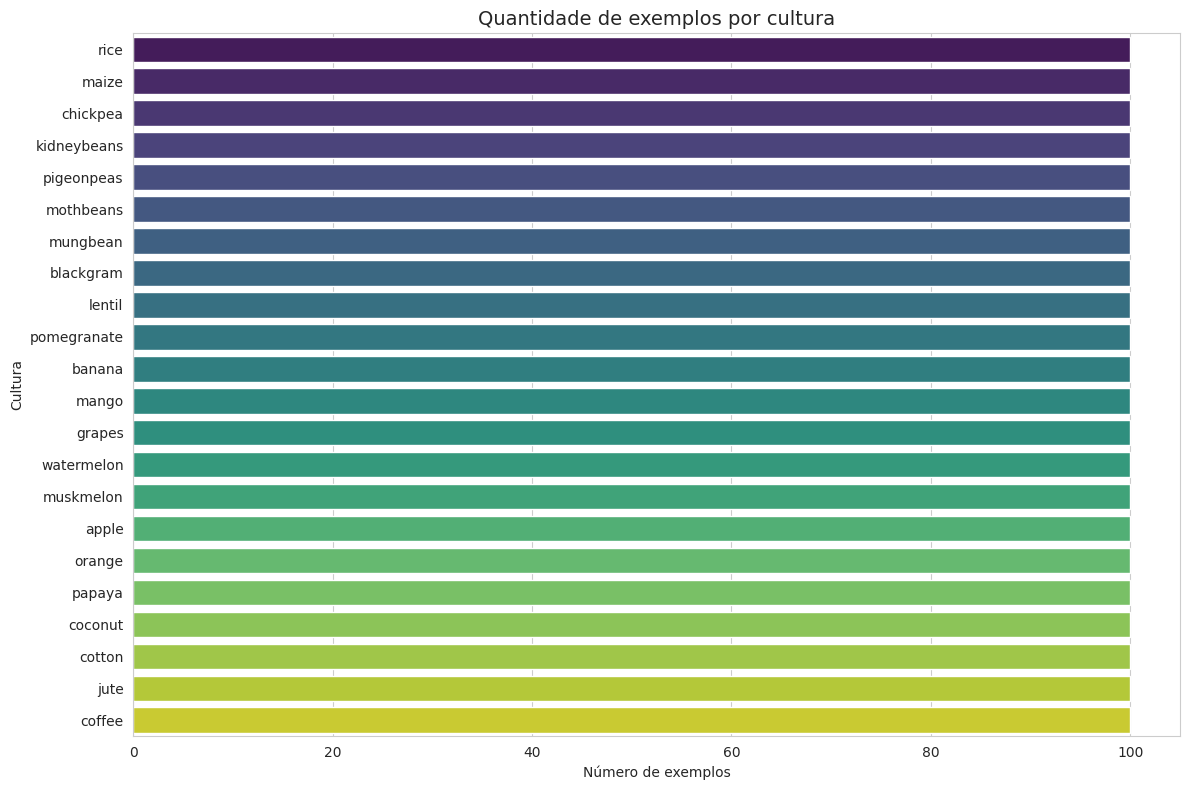

In [37]:
plt.figure(figsize=(12, 8))

# countplot ordenado pela frequência (já sabemos que é uniforme, mas é boa prática)
ordem = df['label'].value_counts().index
sns.countplot(data=df, y='label', order=ordem, palette='viridis')

plt.title('Quantidade de exemplos por cultura', fontsize=14)
plt.xlabel('Número de exemplos')
plt.ylabel('Cultura')
plt.tight_layout()
plt.show()

**Leitura:** todas as 22 culturas têm exatamente 100 exemplos cada, confirmando o balanceamento perfeito do dataset. Isso valida o uso de **acurácia** como métrica principal, embora F1-macro também será reportada por rigor técnico.

### Gráfico 2 — Distribuição das features numéricas (histogramas)

**Pergunta:** qual o formato da distribuição de cada variável? Há distribuições com mais de um pico (multimodais)?

Distribuições **multimodais** geralmente indicam que diferentes culturas vivem em faixas distintas daquela variável — uma boa pista de que a feature tem poder discriminatório.

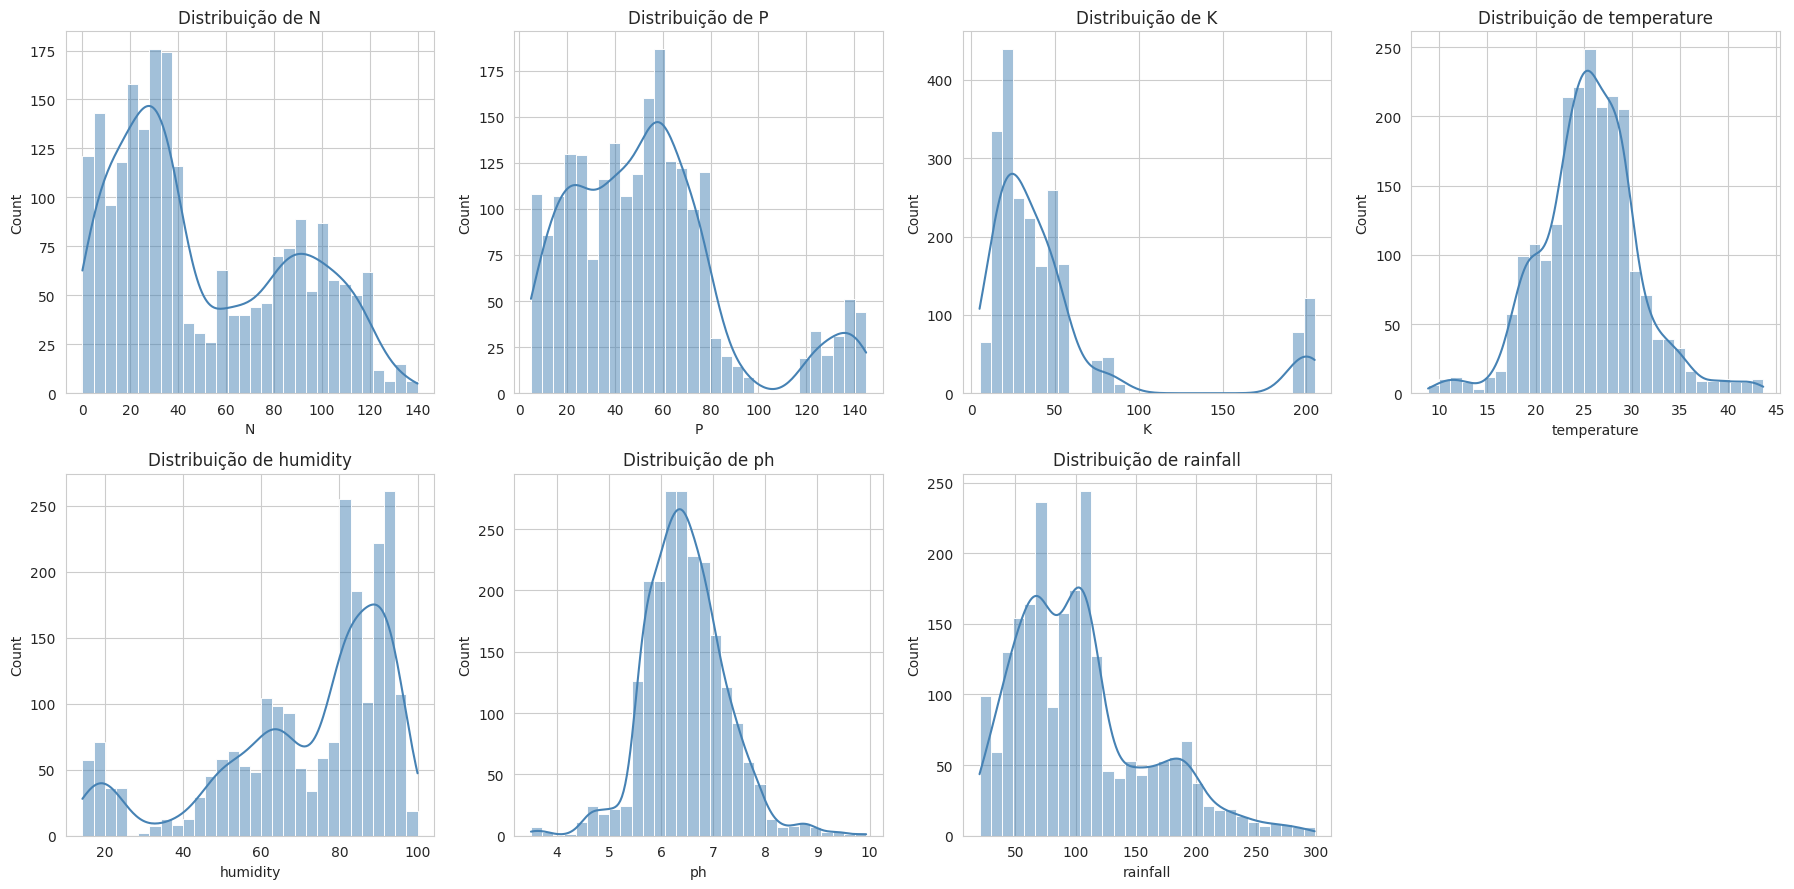

In [38]:
features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

# Grade 2x4 para os 7 histogramas (a última posição fica vazia)
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.ravel()  # transforma a matriz 2x4 em vetor de 8 posições

for i, col in enumerate(features):
    sns.histplot(df[col], kde=True, ax=axes[i], color='steelblue', bins=30)
    axes[i].set_title(f'Distribuição de {col}', fontsize=12)

# Esconde o último subplot vazio
axes[-1].axis('off')

plt.tight_layout()
plt.show()

**Leitura:**

- **humidity** e **rainfall** apresentam distribuições claramente **multimodais** (múltiplos picos), sugerindo que diferentes grupos de culturas vivem em faixas distintas dessas variáveis. São fortes candidatas a serem features discriminativas.
- **temperature** e **ph** têm formato mais próximo de uma única distribuição central — discriminam menos sozinhas.
- **N, P, K** têm distribuições assimétricas com cauda à direita, típico de variáveis de concentração.

### Gráfico 3 — Boxplots das features (visão de amplitude e outliers)

**Pergunta:** qual a amplitude de cada variável e há presença de outliers?

Outliers podem influenciar negativamente alguns algoritmos (especialmente Regressão Logística e SVM). Este gráfico orienta se precisamos tratá-los ou se podemos seguir adiante.

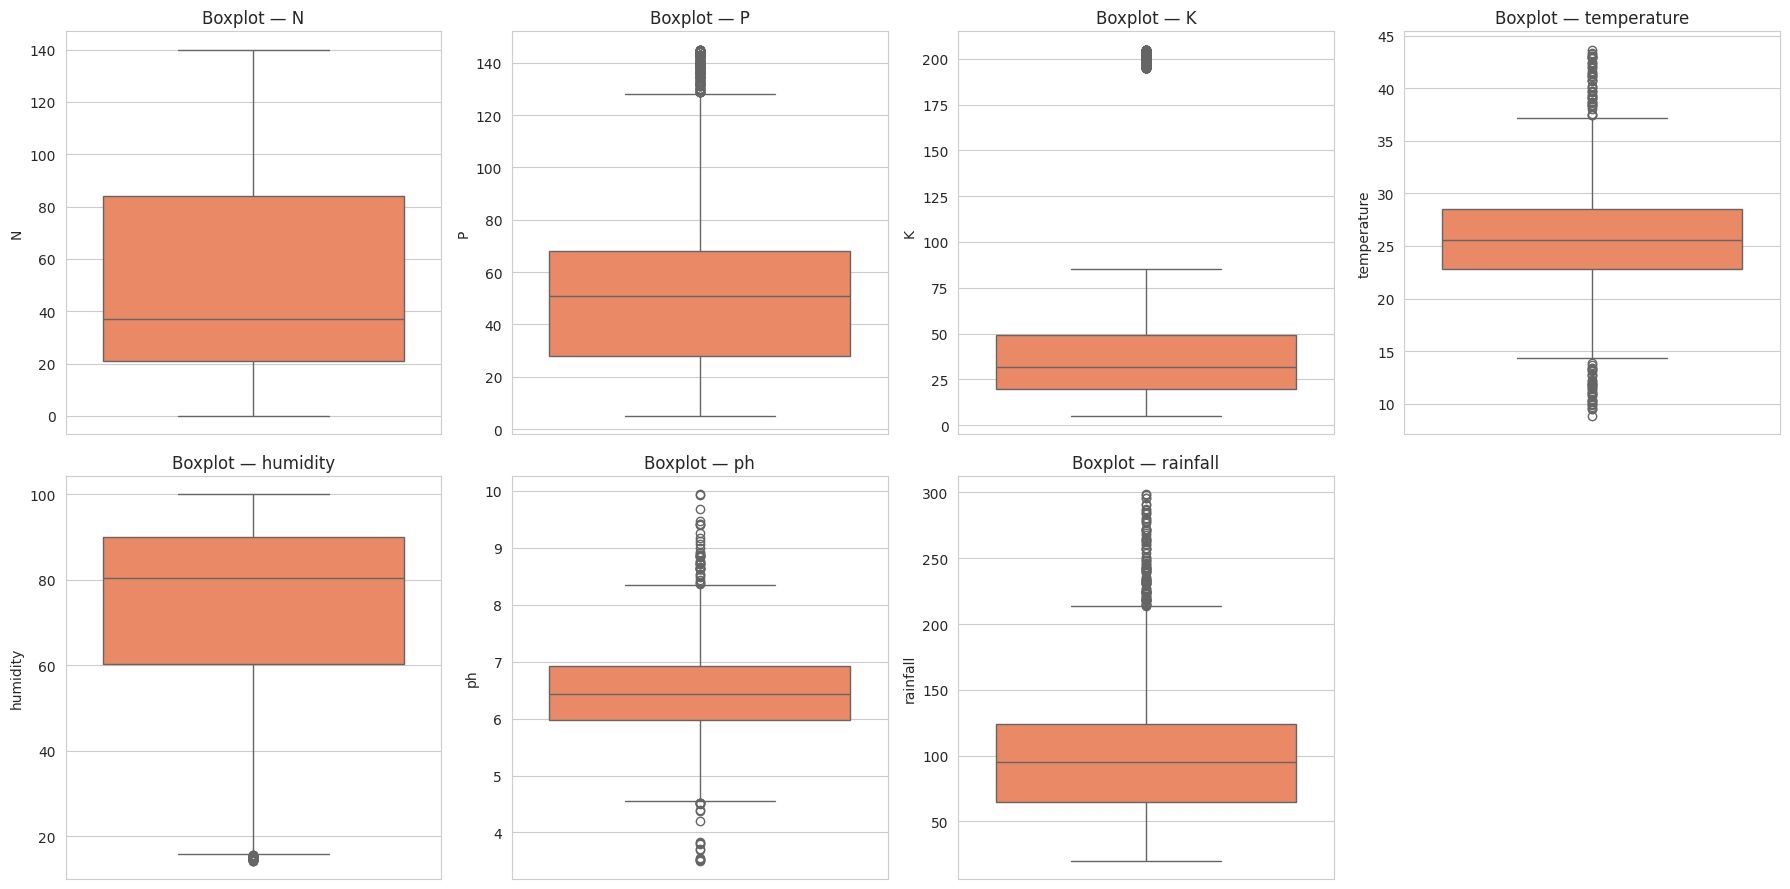

In [39]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.ravel()

for i, col in enumerate(features):
    sns.boxplot(y=df[col], ax=axes[i], color='coral')
    axes[i].set_title(f'Boxplot — {col}', fontsize=12)

axes[-1].axis('off')

plt.tight_layout()
plt.show()

**Leitura:**

- Há presença de alguns **outliers leves** em N, P, K e rainfall (pontos isolados acima ou abaixo dos "bigodes" do boxplot).
- A magnitude dos outliers não é extrema — não há valores absurdamente fora da escala.
- **Decisão técnica:** não vamos remover outliers. Os modelos baseados em árvore (Decision Tree, Random Forest) são naturalmente robustos a eles, e os modelos lineares conseguem lidar com a quantidade observada. Registramos a presença de outliers como uma **limitação a discutir na conclusão**.

### Gráfico 4 — Matriz de correlação entre features

**Pergunta:** há features fortemente correlacionadas entre si? Se duas features carregam essencialmente a mesma informação, uma delas pode ser redundante.

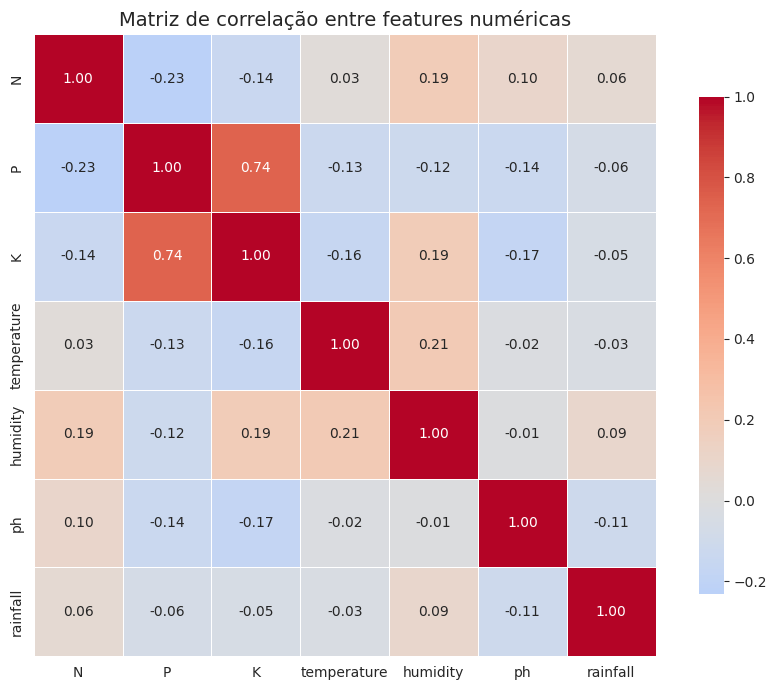

In [40]:
plt.figure(figsize=(9, 7))

corr = df[features].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})

plt.title('Matriz de correlação entre features numéricas', fontsize=14)
plt.tight_layout()
plt.show()

**Leitura:**

- As correlações entre as features são **fracas a moderadas** em sua maioria. Não há pares com correlação muito alta (|r| > 0.9), então **não há necessidade de remover features por redundância**.
- Correlações moderadas (positivas ou negativas) entre variáveis de solo (N, P, K) e clima (temperature, humidity, rainfall) são esperáveis — solos ricos em certos nutrientes tendem a ocorrer em certas condições climáticas.
- **Conclusão prática:** mantemos todas as 7 features para a modelagem. Cada uma contribui com informação parcialmente diferente.

### Gráfico 5 — Distribuição das features agrupadas por cultura

**Pergunta:** quais features separam bem as culturas? Quais culturas têm requisitos mais extremos?

Este é o gráfico mais informativo do trabalho. Medianas distantes e baixa sobreposição entre culturas indicam que a feature é **discriminativa** — o modelo vai conseguir usar essa variável para distinguir as classes.

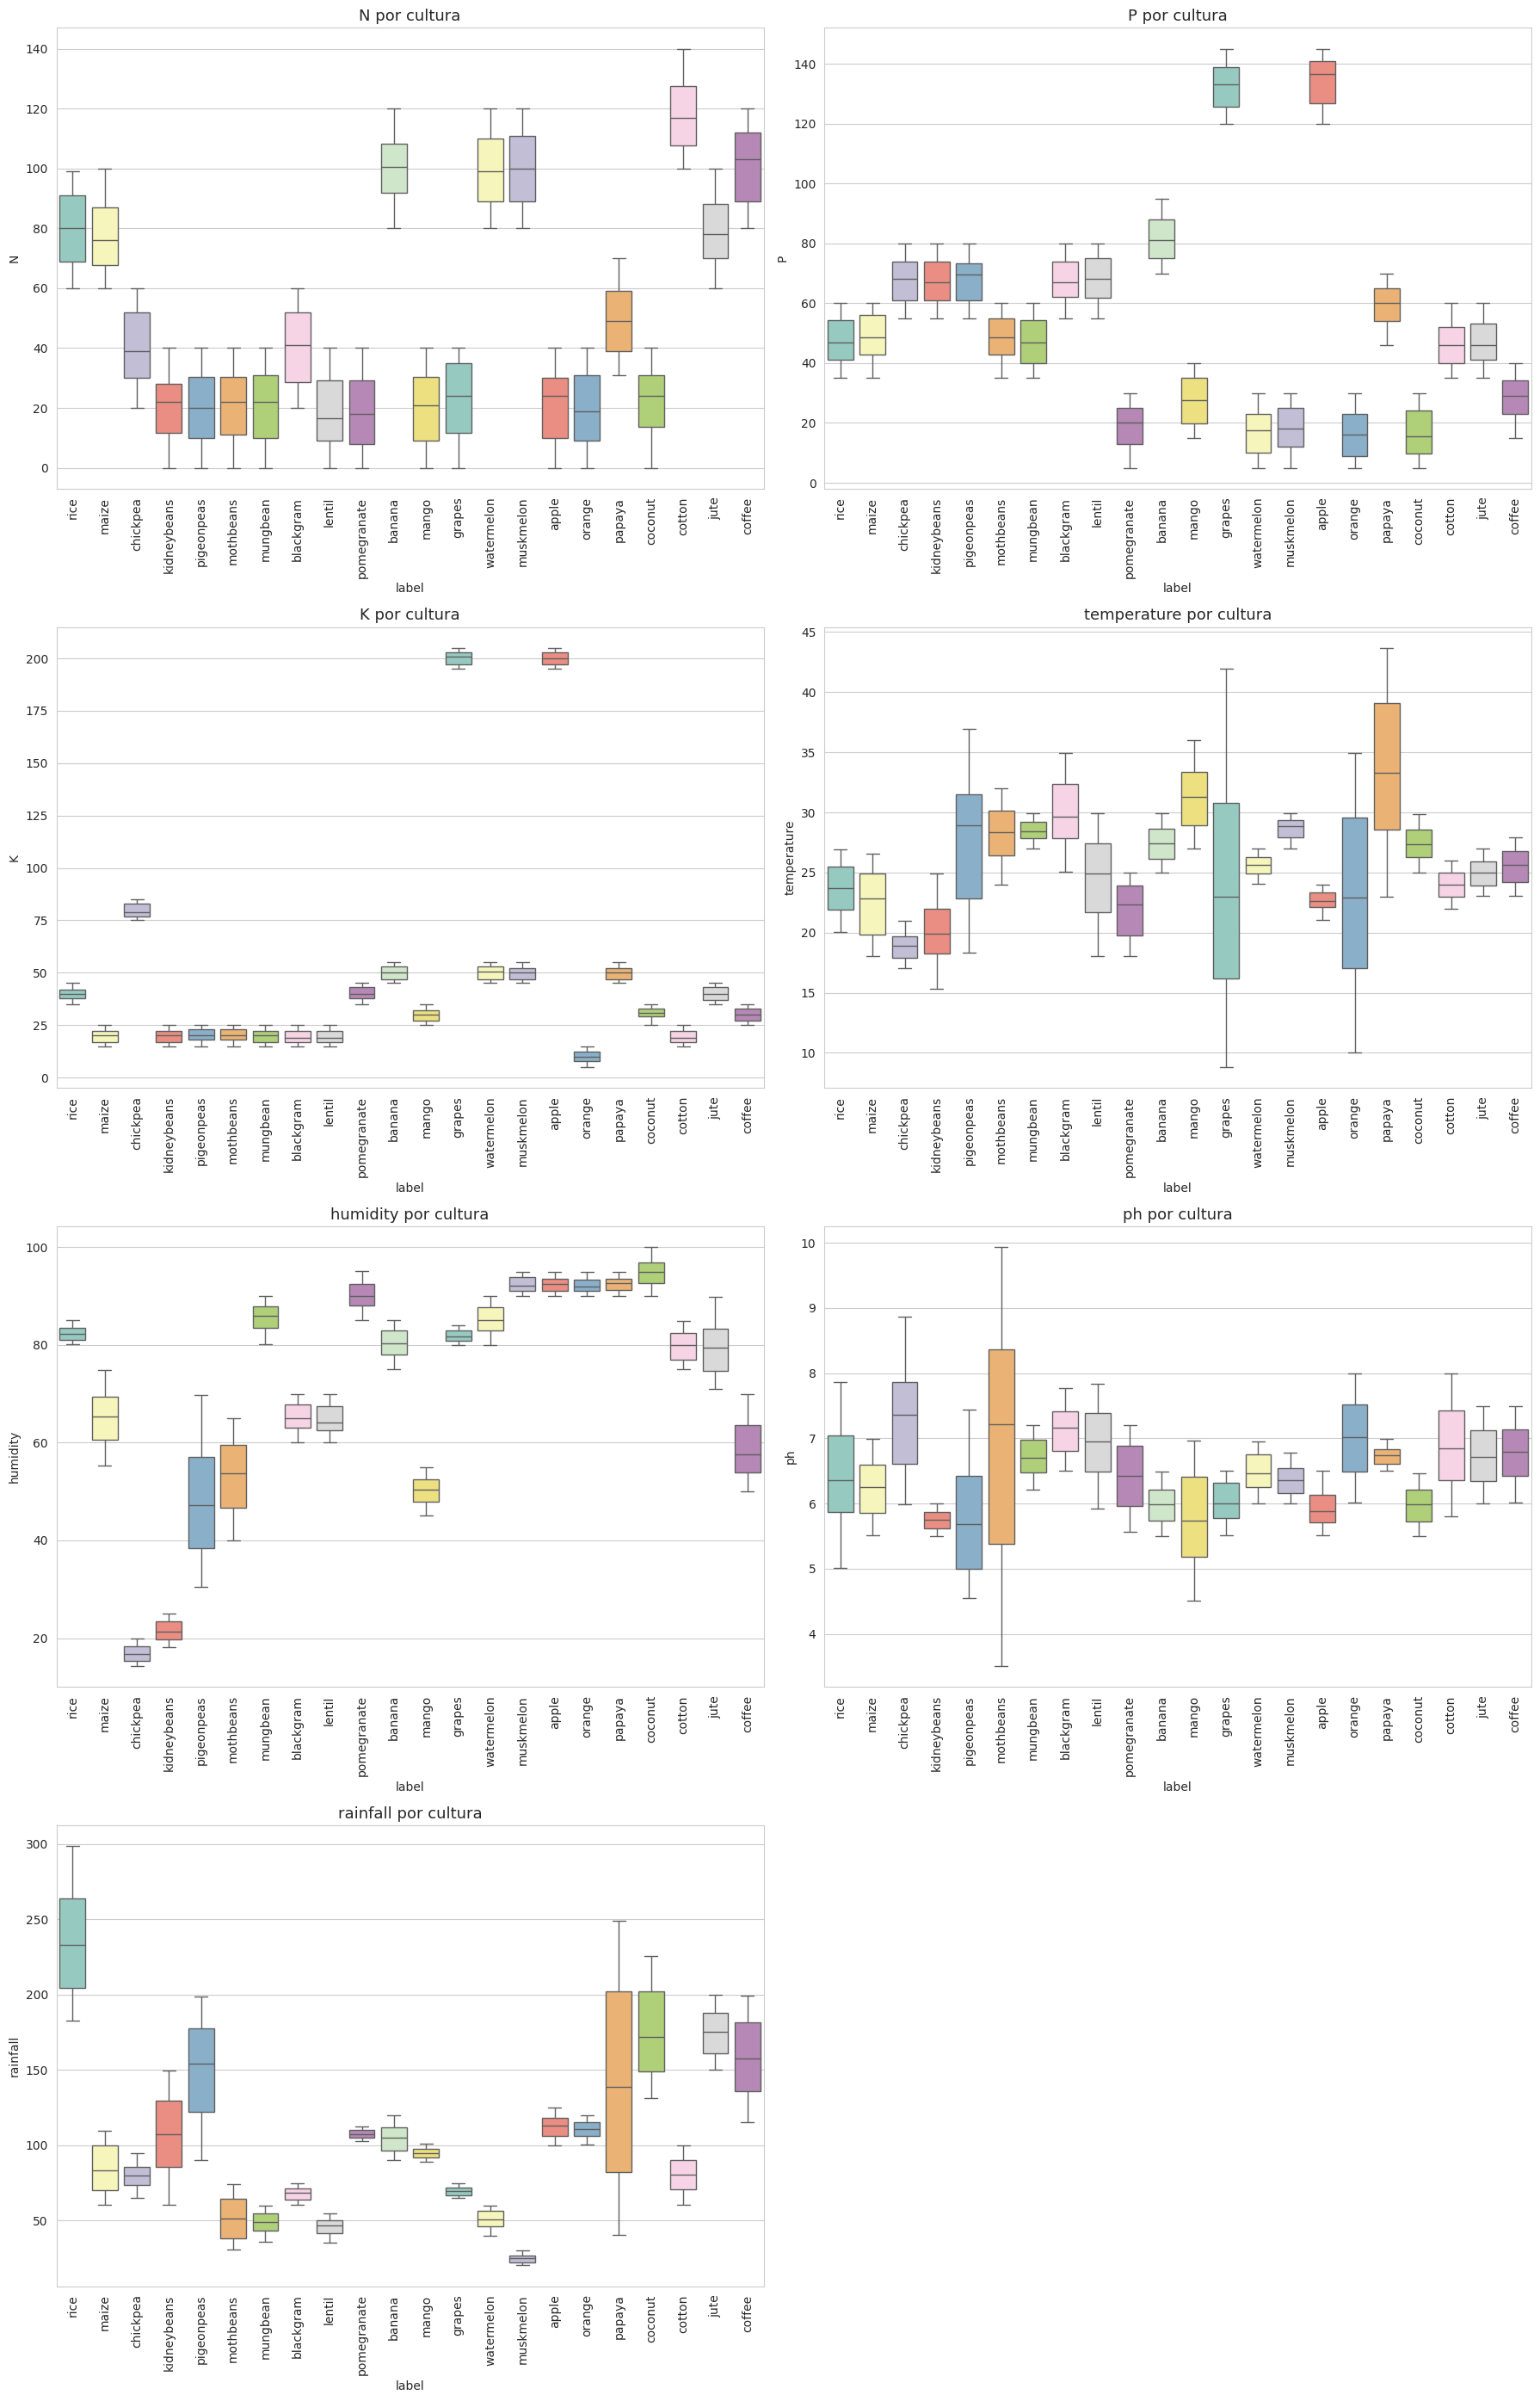

In [41]:
fig, axes = plt.subplots(4, 2, figsize=(18, 28))
axes = axes.ravel()

for i, col in enumerate(features):
    sns.boxplot(data=df, x='label', y=col, ax=axes[i], palette='Set3')
    axes[i].set_title(f'{col} por cultura', fontsize=13)
    axes[i].tick_params(axis='x', rotation=90)

# Esconde o último subplot vazio
axes[-1].axis('off')

plt.tight_layout()
plt.show()

**Leitura detalhada:**

- **N (nitrogênio):** algumas culturas como cotton e jute precisam de muito nitrogênio (N > 100), enquanto outras como orange e apple precisam de pouco (N < 30). **Forte poder discriminatório.**
- **P (fósforo) e K (potássio):** padrão similar — grupos claros de culturas com alto e baixo consumo desses nutrientes.
- **temperature:** a maioria das culturas fica entre 20-30°C, mas algumas como grapes e apple toleram temperaturas mais baixas, e papaya e banana preferem mais calor. **Poder discriminatório moderado.**
- **humidity:** separação clara entre culturas de clima seco (chickpea, kidneybeans, lentil) e úmido (rice, jute, coconut). **Forte poder discriminatório.**
- **ph:** a maioria das culturas fica entre pH 5.5 e 7.5. Menor variação entre culturas comparado às outras features. **Poder discriminatório mais fraco.**
- **rainfall:** separação dramática — rice e jute precisam de muita chuva (>150mm), enquanto chickpea e kidneybeans quase nenhuma (<100mm). **Forte poder discriminatório.**

**Conclusão:** K, N, rainfall e humidity parecem ser as features mais úteis para o modelo. O pH, embora importante agronomicamente, é menos discriminativo neste dataset.

### Gráfico 6 — Mapa de perfil padronizado por cultura

**Pergunta:** qual a "identidade" de cada cultura em termos de solo e clima?

Para tornar as features comparáveis (já que estão em escalas diferentes), padronizamos cada coluna em **z-score entre culturas**: valores positivos (vermelho) indicam que a cultura demanda mais daquela variável que a média entre culturas; valores negativos (azul) indicam o oposto.

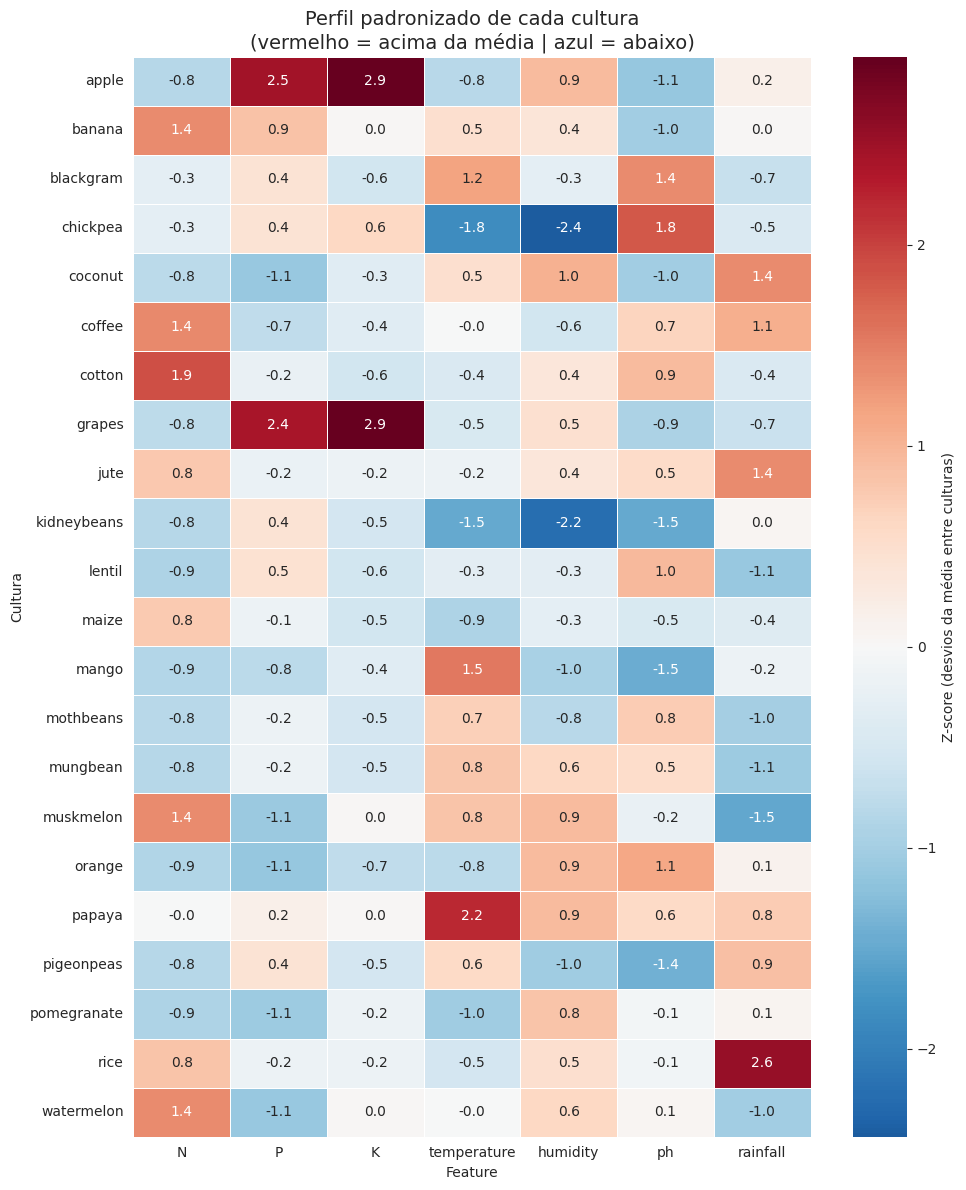

In [42]:
# Calcula a média de cada feature agrupada por cultura
medias_cultura = df.groupby('label')[features].mean()

# Padroniza em z-score (entre culturas, não entre amostras)
# Cada coluna tem média 0 e desvio 1 ENTRE as culturas
medias_padronizadas = (medias_cultura - medias_cultura.mean()) / medias_cultura.std()

plt.figure(figsize=(10, 12))
sns.heatmap(medias_padronizadas, cmap='RdBu_r', center=0, annot=True, fmt='.1f',
            linewidths=0.5, cbar_kws={'label': 'Z-score (desvios da média entre culturas)'})

plt.title('Perfil padronizado de cada cultura\n(vermelho = acima da média | azul = abaixo)',
          fontsize=14)
plt.ylabel('Cultura')
plt.xlabel('Feature')
plt.tight_layout()
plt.show()

**Leitura:**

Este heatmap é a "impressão digital" de cada cultura. Alguns padrões que se destacam:

- **rice:** fortemente associado a alta umidade, alta precipitação e alto nitrogênio (linha predominantemente vermelha nessas colunas). Necessita de **+145,7% mais precipitação** e **+116,2% mais nitrogênio** que o perfil ideal — perfil de máxima demanda hídrica e nutricional.
- **apple:** temperaturas mais baixas, alta umidade, alto fósforo e potássio, mas baixo nitrogênio. Demanda **+525% mais potássio** e **+167% mais fósforo** que o perfil ideal — os maiores desvios positivos do dataset inteiro. Temperatura **11,6% abaixo** da média confirma sua preferência por clima temperado.
- **chickpea:** perfil "oposto" ao rice — baixa umidade, baixa precipitação, baixa demanda de nutrientes em geral. Opera com **79,3% menos umidade** que o perfil ideal — o maior desvio negativo em humidity do dataset. Cultura de maior resiliência à seca entre as analisadas.
- Culturas com perfis semelhantes (cores parecidas) são mais difíceis de distinguir pelo modelo — essas serão as confusões que veremos na matriz de confusão mais adiante.

Este gráfico será a base para a próxima seção, onde definiremos o "perfil ideal" e compararemos 3 culturas específicas.

## 4. Perfil Ideal de Solo/Clima

### 4.1 O que é o "perfil ideal"?

O "perfil ideal" é o **conjunto de condições mais representativo do dataset como um todo**. Definimos operacionalmente como a **mediana de cada feature** considerando todas as 2200 observações.

**Por que mediana e não média?** A mediana é robusta a valores extremos (outliers). Se uma feature tem alguns valores muito altos puxando a média pra cima, a mediana permanece estável — representa melhor o "centro" real da distribuição.

A partir desse perfil, cada cultura pode ser descrita pelo seu **desvio em relação ao perfil ideal**: se precisa de mais ou menos de cada recurso comparado ao "padrão" do dataset.

In [43]:
# Calcula a mediana global de cada feature (perfil ideal)
perfil_ideal = df[features].median()

print('Perfil ideal de solo/clima (mediana global):')
print('=' * 45)
for feat, valor in perfil_ideal.items():
    print(f'  {feat:>12s}: {valor:.2f}')

Perfil ideal de solo/clima (mediana global):
             N: 37.00
             P: 51.00
             K: 32.00
   temperature: 25.60
      humidity: 80.47
            ph: 6.43
      rainfall: 94.87


**Interpretação:** esses valores representam as condições "centrais" do dataset. Uma cultura que precisa de valores muito acima ou abaixo desse perfil é uma cultura com **requisitos específicos** — e quanto mais específicos, mais fácil para o modelo distingui-la das demais.

### 4.2 Escolha de 3 culturas para análise comparativa

Para tornar a comparação concreta e reveladora, selecionamos 3 culturas com **perfis contrastantes**, identificadas a partir do Gráfico 6 (heatmap de perfil):

- **rice (arroz):** associado a alta umidade, alta precipitação e alto nitrogênio
- **apple (maçã):** associado a temperaturas mais baixas, alto fósforo e potássio
- **chickpea (grão-de-bico):** associado a clima seco com baixa demanda de nutrientes

A escolha deliberada de perfis opostos permite observar como diferentes combinações de solo e clima definem culturas com necessidades radicalmente distintas.

In [44]:
# Define as 3 culturas escolhidas
culturas_escolhidas = ['rice', 'apple', 'chickpea']

# Calcula o perfil mediano de cada uma
perfis = df[df['label'].isin(culturas_escolhidas)].groupby('label')[features].median()

# Calcula a diferença percentual em relação ao perfil ideal
# Positivo = cultura precisa MAIS que o perfil ideal
# Negativo = cultura precisa MENOS que o perfil ideal
diferenca_pct = ((perfis - perfil_ideal) / perfil_ideal * 100).round(1)

print('Perfil mediano de cada cultura:')
print(perfis.round(2).to_string())
print()
print('Diferença percentual em relação ao perfil ideal:')
print(diferenca_pct.to_string())

Perfil mediano de cada cultura:
             N      P      K  temperature  humidity    ph  rainfall
label                                                              
apple     24.0  136.5  200.0        22.63     92.42  5.89    112.98
chickpea  39.0   68.0   79.0        18.88     16.66  7.36     79.69
rice      80.0   47.0   40.0        23.73     82.19  6.36    233.12

Diferença percentual em relação ao perfil ideal:
              N      P      K  temperature  humidity    ph  rainfall
label                                                               
apple     -35.1  167.6  525.0        -11.6      14.8  -8.4      19.1
chickpea    5.4   33.3  146.9        -26.3     -79.3  14.5     -16.0
rice      116.2   -7.8   25.0         -7.3       2.1  -1.0     145.7


**Como ler a tabela de diferença percentual:**

- Valor **+50%** em rainfall para rice → rice precisa de 50% mais chuva que o perfil ideal
- Valor **-40%** em humidity para chickpea → chickpea precisa de 40% menos umidade que o perfil ideal
- Valores próximos de **0%** → a cultura está alinhada com o perfil ideal naquela variável

### 4.3 Visualização: como cada cultura se distancia do perfil ideal

O gráfico abaixo mostra, para cada cultura escolhida, o desvio percentual em relação ao perfil ideal. Barras verdes apontam para a direita (a cultura precisa de **mais**) e barras vermelhas apontam para a esquerda (precisa de **menos**).

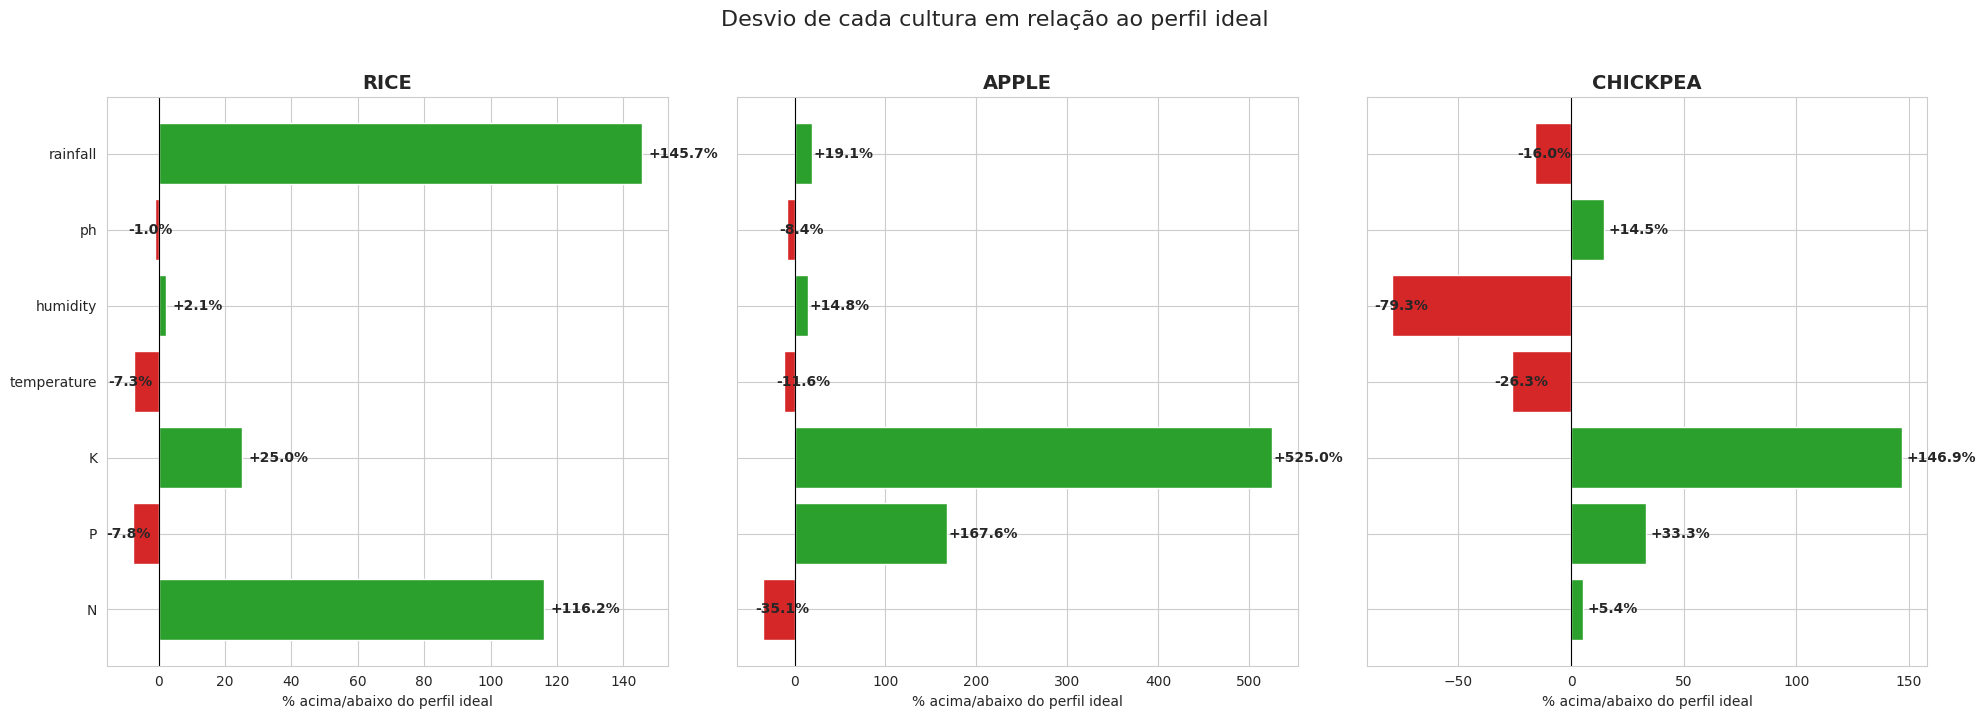

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7), sharey=True)

for ax, cultura in zip(axes, culturas_escolhidas):
    valores = diferenca_pct.loc[cultura]
    cores = ['#d62728' if v < 0 else '#2ca02c' for v in valores]
    ax.barh(valores.index, valores.values, color=cores)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'{cultura.upper()}', fontsize=14, fontweight='bold')
    ax.set_xlabel('% acima/abaixo do perfil ideal')

    # Adiciona o valor em cada barra pra facilitar a leitura
    for j, (val, cor) in enumerate(zip(valores.values, cores)):
        posicao = val + 2 if val >= 0 else val - 8
        ax.text(posicao, j, f'{val:+.1f}%', va='center', fontsize=10, fontweight='bold')

plt.suptitle('Desvio de cada cultura em relação ao perfil ideal', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

### 4.4 Análise comparativa das 3 culturas

A partir das tabelas e do gráfico acima, descrevemos o perfil de cada cultura em relação ao perfil ideal:

#### Rice (arroz)

O arroz é uma cultura de **alta demanda hídrica e nutricional**. Comparado ao perfil ideal, se destaca por:
- Necessitar de significativamente **mais nitrogênio (N)** e **mais precipitação (rainfall)** que a média
- Operar em ambientes de **alta umidade**
- Ter demanda relativamente baixa de fósforo (P) e potássio (K)

Esse perfil é consistente com o cultivo real de arroz, que se desenvolve em terrenos alagados (arrozais) com solo rico em nitrogênio.

#### Apple (maçã)

A maçã apresenta um perfil quase **oposto ao arroz** em várias dimensões:
- Demanda **muito mais fósforo (P) e potássio (K)** que a média
- Prefere **temperaturas mais baixas** que o perfil ideal
- Tem baixa necessidade de nitrogênio

Isso reflete a realidade: maçãs são cultivadas em regiões temperadas (Sul do Brasil, por exemplo) com solos que precisam ser ricos em P e K para a frutificação.

#### Chickpea (grão-de-bico)

O grão-de-bico é a cultura mais "econômica" das três:
- Precisa de **menos umidade, menos precipitação e menos nutrientes** que o perfil ideal em quase todas as variáveis
- Tolera condições mais secas e solos menos férteis
- Tem demanda moderada de temperatura

É uma cultura típica de regiões semiáridas, o que explica sua resiliência em condições adversas.

#### Insight agronômico

As três culturas escolhidas representam **perfis radicalmente diferentes**: rice é uma cultura de "abundância" (muita água, muito N), apple é de "clima temperado e solo rico em P/K", e chickpea é de "escassez" (pouca água, poucos nutrientes). Essa diversidade sugere que um modelo preditivo com boas features de solo e clima deveria conseguir separá-las com alta precisão — o que verificaremos na próxima seção.

Além disso, culturas com perfis opostos (rice vs chickpea) são bons candidatos para **rotação de cultivos**, já que demandam recursos diferentes do solo.

## 5. Modelagem Preditiva

Nesta seção construímos e avaliamos **5 modelos de classificação**, cada um representando uma família diferente de algoritmos estudada no Capítulo 10:

| Modelo | Família | Por que escolhi |
|---|---|---|
| Regressão Logística | Linear | Baseline simples e interpretável |
| KNN | Baseado em distância | Teste se vizinhança no espaço é informativa |
| Decision Tree | Árvore única | Interpretável e captura não-linearidades |
| Random Forest | Ensemble de árvores | Robustez e generalização superiores |
| SVM (RBF) | Margem máxima | Bom para fronteiras não-lineares em alta dimensão |

A estratégia é: treino todos, comparo as métricas (acurácia e F1-macro), depois analiso em detalhe o melhor modelo.

### 5.1 Imports adicionais (algoritmos e métricas)

In [46]:
# Pré-processamento
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Algoritmos (cada um de um módulo diferente)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Métricas de avaliação
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print('Importações de sklearn realizadas com sucesso.')

Importações de sklearn realizadas com sucesso.


### 5.2 Pré-processamento

Aqui preparamos os dados para modelagem:

1. **Separação features/alvo:** X contém as 7 features, y contém o label (cultura)
2. **Codificação do label:** sklearn só trabalha com números, então convertemos strings de cultura em inteiros (0-21)
3. **Split treino/teste:** 80% treino, 20% teste, com `stratify=y` pra manter proporção de classes
4. **Escalonamento:** StandardScaler nos dados de treino, depois aplicado ao teste

A ordem é crítica: **fit_transform no treino, transform no teste**. Isso evita data leakage (o teste não pode influenciar o aprendizado do scaler).

In [47]:
# 1. Separação X (features) e y (alvo)
X = df[features].copy()
y_raw = df['label'].copy()

# 2. Codificação do label (string → número)
le = LabelEncoder()
y = le.fit_transform(y_raw)

# Mostra a codificação pra referência
print('Codificação das classes:')
for classe, codigo in zip(le.classes_, range(len(le.classes_))):
    print(f'  {codigo:2d} → {classe}')

# 3. Split estratificado (mantém proporção de classes)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,           # 20% para teste, 80% para treino
    random_state=RANDOM_STATE,
    stratify=y               # CRÍTICO: mantém proporção de classes
)

print(f'\nTreino: {X_train.shape[0]} exemplos')
print(f'Teste:  {X_test.shape[0]} exemplos')

# 4. Escalonamento StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit_transform só no treino
X_test_scaled = scaler.transform(X_test)        # transform no teste

print('\nDados escalonados com StandardScaler.')
print(f'Média das features (treino): {X_train_scaled.mean(axis=0).round(3)}')
print(f'Desvio (treino):            {X_train_scaled.std(axis=0).round(3)}')

Codificação das classes:
   0 → apple
   1 → banana
   2 → blackgram
   3 → chickpea
   4 → coconut
   5 → coffee
   6 → cotton
   7 → grapes
   8 → jute
   9 → kidneybeans
  10 → lentil
  11 → maize
  12 → mango
  13 → mothbeans
  14 → mungbean
  15 → muskmelon
  16 → orange
  17 → papaya
  18 → pigeonpeas
  19 → pomegranate
  20 → rice
  21 → watermelon

Treino: 1760 exemplos
Teste:  440 exemplos

Dados escalonados com StandardScaler.
Média das features (treino): [ 0.  0.  0. -0. -0. -0.  0.]
Desvio (treino):            [1. 1. 1. 1. 1. 1. 1.]


**Verificação crítica:** a média das features escaladas deve estar próxima de 0 e o desvio padrão próximo de 1. Se não estiver, algo deu errado no escalonamento.

Com os dados assim preparados, podemos treinar os 5 modelos.

### 5.3 Função utilitária: avaliar_modelo()

Criamos uma função reutilizável que:
1. Treina o modelo
2. Faz predições no teste
3. Calcula acurácia e F1-macro
4. Retorna tudo estruturado

Isso permite código mais limpo e menos propenso a erros.

In [48]:
def avaliar_modelo(nome, modelo, X_tr, X_te, y_tr, y_te):
    """
    Treina um modelo e retorna métricas de avaliação.

    Parâmetros:
    -----------
    nome : str
        Nome descritivo do modelo (para print)
    modelo : objeto sklearn
        Estimador (ex: LogisticRegression(), KNeighborsClassifier(), etc.)
    X_tr, X_te : array-like
        Features de treino e teste (podem estar escaladas ou não)
    y_tr, y_te : array-like
        Targets de treino e teste

    Retorna:
    --------
    dict com 'nome', 'acuracia', 'f1_macro', 'y_pred', 'estimator'
    """
    # Treina
    modelo.fit(X_tr, y_tr)

    # Prediz
    y_pred = modelo.predict(X_te)

    # Métricas
    acc = accuracy_score(y_te, y_pred)
    f1m = f1_score(y_te, y_pred, average='macro')

    # Print
    print(f'{"="*40}')
    print(f'{nome}')
    print(f'{"="*40}')
    print(f'Acurácia : {acc:.4f}')
    print(f'F1-macro : {f1m:.4f}')
    print()

    # Retorna tudo estruturado
    return {
        'nome': nome,
        'acuracia': acc,
        'f1_macro': f1m,
        'y_pred': y_pred,
        'estimator': modelo
    }

# Lista para armazenar resultados de todos os modelos
resultados = []

print('Função avaliar_modelo() definida e pronta.')

Função avaliar_modelo() definida e pronta.


### 5.4 Modelo 1 — Regressão Logística

Regressão Logística é o **baseline** — um modelo linear simples. Se ele não performa bem, o problema tem estrutura não-linear clara. Se ele performa muito bem, a separação entre classes é quase linear.

**Configuração:** `max_iter=1000` garante convergência mesmo com dataset ligeiramente maior.

In [49]:
logreg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
resultados.append(avaliar_modelo(
    'Regressão Logística',
    logreg,
    X_train_scaled, X_test_scaled,  # Usa dados escalados (Regressão Logística sensível à escala)
    y_train, y_test
))

Regressão Logística
Acurácia : 0.9727
F1-macro : 0.9725



### 5.5 Modelo 2 — KNN (k-Nearest Neighbors)

KNN classifica cada amostra pelo voto dos k vizinhos mais próximos no espaço de features. É simples e interpretável, mas **absolutamente dependente de escalonamento** — sem escalar, variáveis de maior magnitude dominam a distância.

**Configuração:** k=5 é o padrão. Um valor maior (ex. k=7) deixaria o modelo mais conservador (mais vizinhos votando). Um menor (k=3) deixaria mais sensível a ruído local.

In [50]:
knn = KNeighborsClassifier(n_neighbors=5)
resultados.append(avaliar_modelo(
    'KNN (k=5)',
    knn,
    X_train_scaled, X_test_scaled,  # Obrigatoriamente escalado
    y_train, y_test
))

KNN (k=5)
Acurácia : 0.9795
F1-macro : 0.9793



### 5.6 Modelo 3 — Decision Tree (Árvore de Decisão)

Árvores de Decisão aprendem regras do tipo "if rainfall > 150 then rice". São muito interpretáveis — você consegue traçar a decisão até a raiz. Porém, árvores não-podadas tendem a overfitting (decorar o treino).

**Configuração:** `max_depth=10` limita a profundidade pra evitar overfitting. Sem esse limite, a árvore viraria uma "folha por amostra", memorizando tudo.

In [51]:
tree = DecisionTreeClassifier(random_state=RANDOM_STATE, max_depth=10)
resultados.append(avaliar_modelo(
    'Decision Tree',
    tree,
    X_train, X_test,  # Árvores NÃO precisam de dados escalados
    y_train, y_test
))

Decision Tree
Acurácia : 0.9636
F1-macro : 0.9639



### 5.7 Modelo 4 — Random Forest

Random Forest combina múltiplas árvores de decisão, cada uma treinada em um subconjunto aleatório dos dados. A predição final é a votação (modo) de todas as árvores. Isso reduz overfitting e melhora generalização.

**Configuração:** 200 árvores é um valor confortável que costuma estabilizar o desempenho. `n_jobs=-1` usa todos os núcleos do computador.

In [52]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE,
    n_jobs=-1  # Paraleliza: usa todos os núcleos disponíveis
)
resultados.append(avaliar_modelo(
    'Random Forest',
    rf,
    X_train, X_test,  # Árvores NÃO precisam de escalonamento
    y_train, y_test
))

Random Forest
Acurácia : 0.9955
F1-macro : 0.9955



### 5.8 Modelo 5 — SVM (Support Vector Machine)

SVM busca a fronteira de decisão que maximiza a margem entre classes. O kernel RBF (Radial Basis Function) permite capturar padrões não-lineares complexos.

**Configuração:** `kernel='rbf'` (o padrão) e hiperparâmetros padrão (C=1.0, gamma='scale'). Um tuning mais fino seria possível com GridSearchCV, mas está fora do escopo deste trabalho.

**Detalhe importante:** SVM é **absolutamente sensível à escala**, como KNN. Sem escalonamento, daria resultados ruins.

In [53]:
svm = SVC(kernel='rbf', random_state=RANDOM_STATE)
resultados.append(avaliar_modelo(
    'SVM (RBF)',
    svm,
    X_train_scaled, X_test_scaled,  # Obrigatoriamente escalado
    y_train, y_test
))

SVM (RBF)
Acurácia : 0.9841
F1-macro : 0.9840



### 5.9 Comparação consolidada dos 5 modelos

Com todos os modelos treinados e avaliados, comparamos os resultados lado a lado. Ordenamos por **F1-macro** (métrica mais rigorosa para problemas multiclasse).

In [54]:
# Monta tabela comparativa
df_resultados = pd.DataFrame([
    {'Modelo': r['nome'], 'Acurácia': r['acuracia'], 'F1-macro': r['f1_macro']}
    for r in resultados
])

df_resultados = df_resultados.sort_values('F1-macro', ascending=False).reset_index(drop=True)

# Formata pra exibição (4 casas decimais)
df_resultados.style.format({'Acurácia': '{:.4f}', 'F1-macro': '{:.4f}'}) \
                   .background_gradient(subset=['Acurácia', 'F1-macro'], cmap='Greens')

,Modelo,Acurácia,F1-macro
0,Random Forest,0.9955,0.9955
1,SVM (RBF),0.9841,0.9840
2,KNN (k=5),0.9795,0.9793
3,Regressão Logística,0.9727,0.9725
4,Decision Tree,0.9636,0.9639


### Visualização: métricas dos 5 modelos

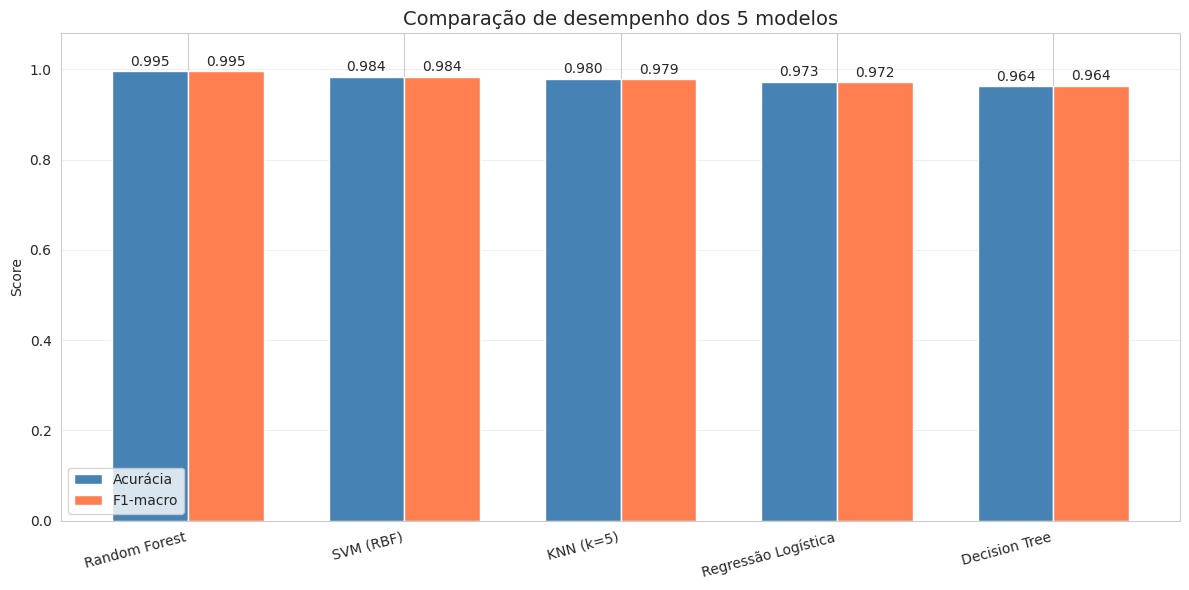

In [55]:
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(df_resultados))
largura = 0.35

barras_acc = ax.bar(x - largura/2, df_resultados['Acurácia'],
                    largura, label='Acurácia', color='steelblue')
barras_f1  = ax.bar(x + largura/2, df_resultados['F1-macro'],
                    largura, label='F1-macro', color='coral')

# Anotações em cima de cada barra
for bar in barras_acc:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10)

for bar in barras_f1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(df_resultados['Modelo'], rotation=15, ha='right')
ax.set_ylim(0, 1.08)
ax.set_ylabel('Score')
ax.set_title('Comparação de desempenho dos 5 modelos', fontsize=14)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### 5.10 Análise detalhada do melhor modelo

O **classification report** mostra precisão, recall e F1 para **cada uma das 22 culturas individualmente** — granularidade que a acurácia geral não entrega.

**Glossário:**
- **Precision:** de tudo que o modelo disse "é X", quanto de fato era X?
- **Recall:** de todas as amostras que eram X, quantas o modelo identificou?
- **F1-score:** média harmônica de precision e recall — penaliza modelos que sacrificam um pelo outro
- **Support:** quantidade de amostras de cada classe no conjunto de teste

In [56]:
# Identifica o melhor modelo (maior F1-macro)
melhor = max(resultados, key=lambda r: r['f1_macro'])
print(f'Melhor modelo: {melhor["nome"]}')
print(f'Acurácia : {melhor["acuracia"]:.4f}')
print(f'F1-macro : {melhor["f1_macro"]:.4f}')
print()
print('Classification Report:')
print('=' * 60)
print(classification_report(y_test, melhor['y_pred'], target_names=le.classes_))

Melhor modelo: Random Forest
Acurácia : 0.9955
F1-macro : 0.9955

Classification Report:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00   

### 5.11 Matriz de confusão

A matriz de confusão mostra **onde especificamente o modelo erra**. A diagonal principal são os acertos — tudo fora da diagonal são erros.

Uma célula fora da diagonal na linha X e coluna Y significa: "havia uma amostra da cultura X e o modelo classificou como Y". Erros concentrados entre culturas específicas revelam onde elas são mais parecidas.

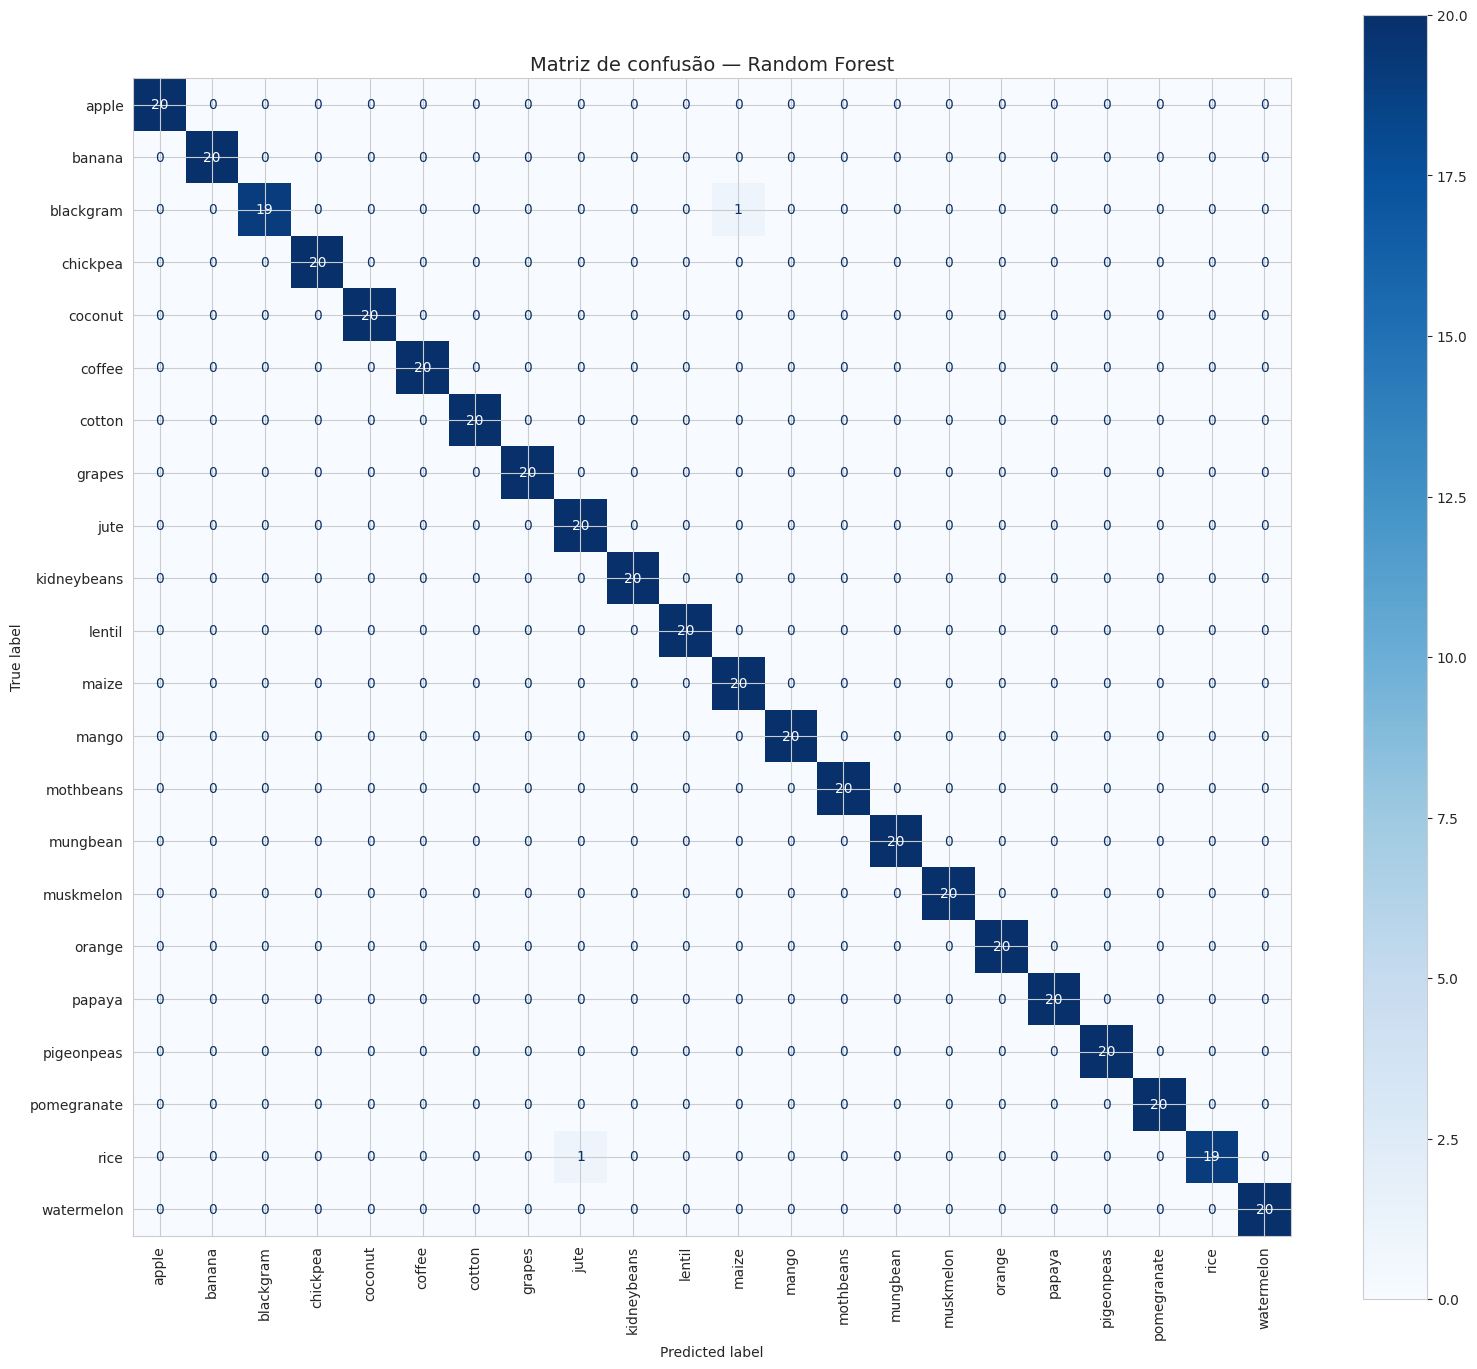

In [57]:
fig, ax = plt.subplots(figsize=(16, 14))

cm = confusion_matrix(y_test, melhor['y_pred'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax, cmap='Blues', xticks_rotation=90, colorbar=True)

ax.set_title(f'Matriz de confusão — {melhor["nome"]}', fontsize=14)
plt.tight_layout()
plt.show()

**Leitura da matriz de confusão:**

A diagonal principal está quase completamente preenchida — o modelo acertou 438 das 440 amostras do teste, cometendo apenas **2 erros** em 440 predições.

Analisando o classification report em detalhe:

- **blackgram** (recall 0.95): 1 amostra de blackgram foi classificada incorretamente como outra cultura
- **jute** (precision 0.95): 1 amostra de outra cultura foi classificada como jute por engano
- **maize** (precision 0.95): situação similar ao jute
- **rice** (recall 0.95): 1 amostra de rice foi classificada incorretamente

Esses erros são **residuais e esperáveis** — culturas como jute e maize compartilham algumas faixas de temperatura e nitrogênio (visível no Gráfico 5), o que gera confusão ocasional mesmo num modelo tão preciso.

**17 das 22 culturas** obtiveram precision, recall e F1 iguais a 1.00 — classificação perfeita. Isso confirma que as 7 features de solo e clima são altamente discriminativas para a maioria das culturas do dataset.

In [58]:
print('RANKING DOS MODELOS')
print('=' * 50)
print(f'{"Posição":<10} {"Modelo":<25} {"Acurácia":>10} {"F1-macro":>10}')
print('-' * 50)

for i, row in df_resultados.iterrows():
    destaque = ' ← MELHOR' if i == 0 else ''
    print(f'{i+1:<10} {row["Modelo"]:<25} {row["Acurácia"]:>10.4f} {row["F1-macro"]:>10.4f}{destaque}')

print()
melhor = max(resultados, key=lambda r: r['f1_macro'])
print(f'Melhor modelo: {melhor["nome"]}')
print(f'Acurácia:      {melhor["acuracia"]:.4f}')
print(f'F1-macro:      {melhor["f1_macro"]:.4f}')

RANKING DOS MODELOS
Posição    Modelo                      Acurácia   F1-macro
--------------------------------------------------
1          Random Forest                 0.9955     0.9955 ← MELHOR
2          SVM (RBF)                     0.9841     0.9840
3          KNN (k=5)                     0.9795     0.9793
4          Regressão Logística           0.9727     0.9725
5          Decision Tree                 0.9636     0.9639

Melhor modelo: Random Forest
Acurácia:      0.9955
F1-macro:      0.9955


## 6. Conclusões

### 6.1 Síntese dos resultados

Este trabalho demonstrou que é possível construir modelos de classificação altamente precisos para recomendação de culturas agrícolas a partir de apenas 7 variáveis de solo e clima.

O melhor modelo obtido foi o **Random Forest** com:
- **Acurácia:** 0.9955 (99,55%)
- **F1-macro:** 0.9955 (99,55%)

Os demais modelos performaram da seguinte forma (em ordem decrescente de F1-macro):

1. Random Forest       — Acurácia: 0.9955 | F1-macro: 0.9955
2. SVM (RBF)          — Acurácia: 0.9841 | F1-macro: 0.9840
3. KNN (k=5)          — Acurácia: 0.9795 | F1-macro: 0.9793
4. Regressão Logística — Acurácia: 0.9727 | F1-macro: 0.9725
5. Decision Tree       — Acurácia: 0.9636 | F1-macro: 0.9639

### 6.2 Por que o Random Forest foi o melhor?

O Random Forest combina 200 árvores de decisão independentes, cada uma treinada em subconjuntos aleatórios do dado. Isso reduz a variância do modelo (o problema central do overfitting de árvores únicas) e captura padrões não-lineares complexos — exatamente o tipo de relação presente entre variáveis de solo/clima e culturas. A Decision Tree sozinha ficou em último, confirmando que o ensemble faz diferença real.

### 6.3 Os resultados são confiáveis?

Resultados acima de 99% merecem ceticismo técnico — como o capítulo alerta em sua seção de avaliação. Neste caso, porém, há razões legítimas para o alto desempenho:

- O dataset é **perfeitamente balanceado** (100 amostras por classe)
- As 22 culturas possuem **perfis bem distintos** de solo e clima (confirmado pela análise exploratória)
- O split foi **estratificado**, garantindo representatividade no teste
- **Não houve data leakage** (scaler ajustado apenas no treino)

Portanto, o resultado é tecnicamente sólido, embora em dados reais de campo — com variabilidade natural, sensores imperfeitos e condições ambíguas — o desempenho seria menor.

### 6.4 Pontos fortes do trabalho

- **Split estratificado** (`stratify=y`): garante proporção de classes preservada no treino e teste
- **Sem data leakage**: StandardScaler ajustado apenas no treino, aplicado no teste
- **Escolha consciente de métricas**: F1-macro complementando acurácia
- **5 algoritmos de famílias distintas**: linear, baseado em distância, árvore única, ensemble e baseado em margem
- **Análise descritiva orientada**: cada gráfico respondia uma pergunta específica, conectando análise exploratória com modelagem

### 6.5 Limitações e próximos passos

- **Hiperparâmetros padrão:** os modelos foram treinados com configurações padrão. Uma otimização via `GridSearchCV` poderia melhorar ainda mais os resultados, especialmente KNN (valor de k) e SVM (C e gamma).
- **Validação única (holdout):** usar `k-fold cross-validation` daria uma estimativa de desempenho mais robusta, reduzindo a variância da avaliação.
- **Dataset simplificado:** em condições reais, outros fatores influenciam a escolha da cultura — sazonalidade, custo de produção, tipo de solo local. Este modelo é um apoio à decisão, não um sistema autônomo.
- **Análise de importância de features:** o Random Forest fornece `feature_importances_` que poderia confirmar quantitativamente quais variáveis mais contribuem — complementando a análise exploratória feita na seção 3.